# EDA

## Necessary Packages (**EDIT?**)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Dataset Load

In [27]:
# Load the clean datasets
all_players = pd.read_csv("../Data/Clean/All_Players.csv")
judge_only = pd.read_csv("../Data/Clean/Judge_Only.csv")

## Correlation Matrix Heatmap

For two random variables $X_1$ and $X_2$, each with $N$ observations, the Pearson correlation coefficient is defined as

$$
\rho_{X_1,\,X_2}=\frac{\mathrm{Cov}(X_1,\,X_2)}{s_{X_1}\cdot s_{X_2}} \tag*{(1)}
$$

where $s_{X_1},\,s_{X_2}$ are the sample standard deviations of the $X_1$ and $X_2$ distributions, respectively, and

$$
\mathrm{Cov}(X_1,\,X_2)=\frac{1}{N-1}\sum_{i=1}^N\,(x_{1i}-\overline{x}_1)(x_{2i}-\overline{x}_2) \tag*{(2)}
$$

is the sample covariance between $X_1$ and $X_2$ where $\overline{x}_1,\,\overline{x}_2$ are the means of $X_1$ and $X_2$, respectively.

In [38]:
# Compute the correlation matrix using the Pearson method
corr = all_players.iloc[:, 3:].corr(method = "pearson")

# Initialize a heatmap plot of the correlation matrix
heatmap = px.imshow(corr)

# Customize the heatmap plot
heatmap.update_layout(title = dict(text = "Correlation Matrix Heatmap for All Hitter Seasons (2017-2024)",
                                   x = 0.5,
                                   y = 0.95),
                      template = "plotly_dark",
                      width = 1000,
                      height = 1000,
                      xaxis_tickangle = 45,
                      coloraxis_colorbar = dict(len = 0.5,
                                                thickness = 15))
heatmap.update_xaxes(tickfont = dict(size = 6))
heatmap.update_yaxes(tickfont = dict(size = 6))
heatmap.update_traces(hovertemplate = "X_1: %{x}<br>X_2: %{y}<br>ρ = %{z:.3f}<extra></extra>")

# Show the heatmap plot
heatmap.show()

## Univariate Distributions

...

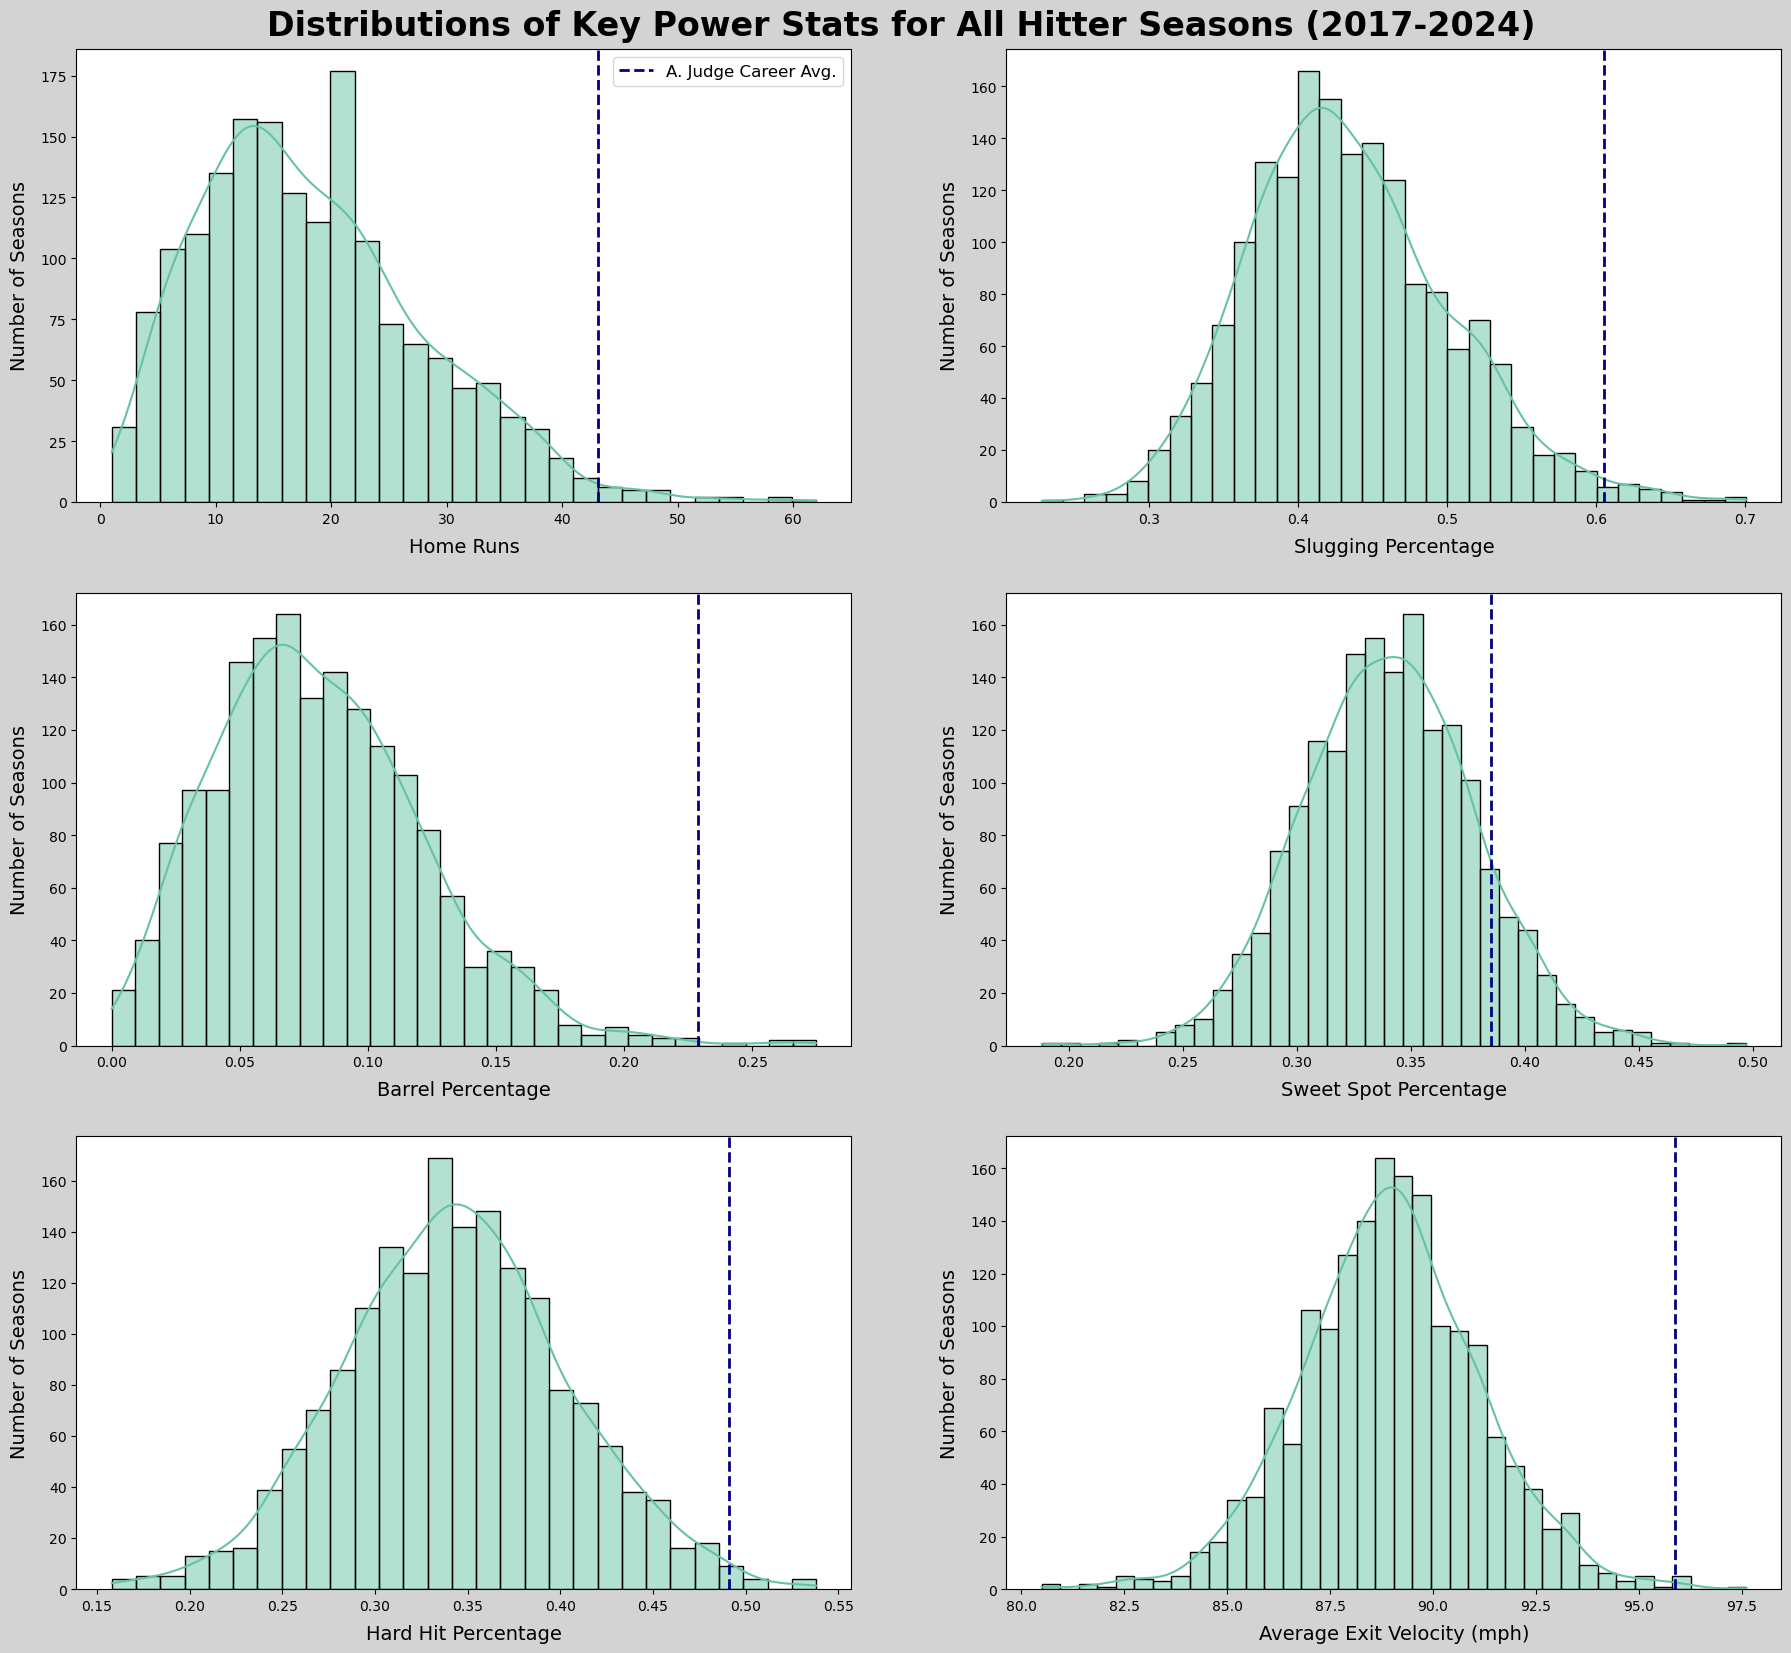

In [125]:
# Define the key power stats to visualize
key_stats = {"home_runs": "Home Runs",
             "slugging_percentage": "Slugging Percentage",
             "barrel_percentage": "Barrel Percentage",
             "sweet_spot_percentage": "Sweet Spot Percentage",
             "hard_hit_percentage": "Hard Hit Percentage",
             "average_exit_velocity": "Average Exit Velocity (mph)"}

# Set the Seaborn color palette 
sns.set_palette("Set2")

# Initialize the overall figure 
plt.figure(figsize = (22, 20), facecolor = "lightgray")

# Compute Aaron Judge career averages for each power stat
judge_avg = judge_only[list(key_stats.keys())].mean()

# Create subplots for each power stat
for i, (col, label) in enumerate(key_stats.items(), 1):
    plt.subplot(3, 2, i)

    # Make each subplot a histogram with kernel density estimation (KDE)
    sns.histplot(all_players[col], stat = "count", kde = True, alpha = 0.5)
    
    # Highlight Judge's average with a vertical and dashed navy blue line (for NYY)
    plt.axvline(judge_avg[col],
                color = "navy",
                linestyle = "--",
                linewidth = 2,
                label = "A. Judge Career Avg.")

    # Customize the histogram subplots    
    plt.xlabel(label, fontsize = 14, labelpad = 8)
    plt.ylabel("Number of Seasons", fontsize = 14, labelpad = 8)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    
    # Add a legend only to first subplot to avoid repetition across all subplots
    if i == 1:
        plt.legend(fontsize = 12, loc = "upper right")

# Customize the overall figure
plt.suptitle("Distributions of Key Power Stats for All Hitter Seasons (2017-2024)", 
             fontsize = 24,
             fontweight = "bold", 
             y = 0.9)

# Show the overall figure
plt.show()